# Risk-Oriented Exploratory Data Analysis — HPG, FPT, MWG

## Mục tiêu

Notebook này mở rộng phần EDA cơ bản bằng các phân tích định hướng rủi ro cho HPG, FPT và MWG.

Nội dung gồm:

- Phân tích outlier dựa trên daily log return.
- Phân tích tương quan lợi suất.
- Rolling volatility 20 phiên.
- Phân tích phần đuôi của phân phối lợi suất.
- Bổ sung các biến dẫn xuất cho Data Dictionary.

Các quan sát cực đoan không bị tự động xóa.

> Extreme return không đồng nghĩa với bad data. Những phiên biến động mạnh có thể chứa thông tin quan trọng về rủi ro thị trường, sự kiện doanh nghiệp hoặc corporate action.

In [94]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "eda"
DATA_DICTIONARY_PATH = (
    PROJECT_ROOT / "docs" / "data-dictionary-v0.1.csv"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TICKERS = ["HPG", "FPT", "MWG"]

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/admin/Documents/project/portfolio-var-risk-system
Processed data: /Users/admin/Documents/project/portfolio-var-risk-system/data/processed
Figure directory: /Users/admin/Documents/project/portfolio-var-risk-system/figures/eda


## 1. Đọc dữ liệu đã được xử lý

Notebook sử dụng dữ liệu đã qua validation:

- `data/processed/HPG_clean.csv`
- `data/processed/FPT_clean.csv`
- `data/processed/MWG_clean.csv`

Dữ liệu gốc không bị thay đổi trong notebook này.

In [95]:
frames = []

for ticker in TICKERS:
    file_path = DATA_DIR / f"{ticker}_clean.csv"

    if not file_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy file: {file_path}"
        )

    data = pd.read_csv(file_path)

    data.columns = [
        str(column).strip().lower()
        for column in data.columns
    ]

    if "date" in data.columns and "time" not in data.columns:
        data = data.rename(columns={"date": "time"})

    required_columns = {
        "time",
        "open",
        "high",
        "low",
        "close",
        "volume",
    }

    missing_columns = required_columns.difference(
        data.columns
    )

    if missing_columns:
        raise ValueError(
            f"{ticker} thiếu cột: "
            f"{sorted(missing_columns)}"
        )

    data["time"] = pd.to_datetime(
        data["time"],
        errors="coerce",
    )

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
    ]

    for column in numeric_columns:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce",
        )

    data["ticker"] = ticker

    frames.append(data)


market_data = (
    pd.concat(
        frames,
        ignore_index=True,
    )
    .sort_values(
        ["ticker", "time"]
    )
    .reset_index(drop=True)
)

print("Kích thước dữ liệu:", market_data.shape)

market_data.head()

Kích thước dữ liệu: (4914, 7)


,time,ticker,open,high,low,close,volume
0,2020-01-02,FPT,20.79,21.04,20.68,20.90,896720
1,2020-01-03,FPT,21.00,21.08,20.47,20.54,2047880
2,2020-01-06,FPT,20.36,20.54,20.26,20.33,1091660
3,2020-01-07,FPT,20.43,20.72,20.33,20.72,837240
4,2020-01-08,FPT,20.50,20.58,20.26,20.26,1814290


Tổng quan dữ liệu

In [96]:
data_overview = (
    market_data
    .groupby("ticker")
    .agg(
        observations=("time", "size"),
        start_date=("time", "min"),
        end_date=("time", "max"),
        duplicate_dates=(
            "time",
            lambda series: series.duplicated().sum(),
        ),
        missing_close=(
            "close",
            lambda series: series.isna().sum(),
        ),
    )
)

data_overview

,observations,start_date,end_date,duplicate_dates,missing_close
ticker,,,,,
FPT,1638,2020-01-02,2026-07-28,0,0
HPG,1638,2020-01-02,2026-07-28,0,0
MWG,1638,2020-01-02,2026-07-28,0,0


## 2. Tính Daily Log Return

Lợi suất log ngày được tính theo công thức:

\[
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
\]

Trong đó:

- \(P_t\): giá đóng cửa tại ngày hiện tại.
- \(P_{t-1}\): giá đóng cửa tại ngày trước đó.

Quan sát đầu tiên của mỗi ticker không có giá ngày trước nên return sẽ là giá trị thiếu.

In [97]:
market_data["previous_close"] = (
    market_data
    .groupby("ticker")["close"]
    .shift(1)
)

market_data["log_return"] = np.log(
    market_data["close"]
    / market_data["previous_close"]
)

market_data["normalized_price"] = (
    market_data
    .groupby("ticker")["close"]
    .transform(
        lambda series: (
            series / series.iloc[0]
        ) * 100
    )
)

returns_data = (
    market_data
    .dropna(subset=["log_return"])
    .copy()
)

return_quality_check = (
    market_data
    .groupby("ticker")
    .agg(
        observations=("time", "size"),
        valid_returns=("log_return", "count"),
        missing_returns=(
            "log_return",
            lambda series: series.isna().sum(),
        ),
    )
)

return_quality_check

,observations,valid_returns,missing_returns
ticker,,,
FPT,1638,1637,1
HPG,1638,1637,1
MWG,1638,1637,1


tạo bảng return theo ngày

In [98]:
return_matrix = (
    returns_data
    .pivot(
        index="time",
        columns="ticker",
        values="log_return",
    )
    .sort_index()
)

return_matrix.head()

ticker,FPT,HPG,MWG
time,,,
2020-01-03,-0.017375,0.006752,-0.014688
2020-01-06,-0.010277,-0.006752,-0.005038
2020-01-07,0.019002,-0.012270,0.007826
2020-01-08,-0.022451,-0.011035,-0.024519
2020-01-09,0.013726,0.023305,0.015008


## 3. B1 — Outlier Analysis

Phần này kiểm tra:

- Return nhỏ nhất.
- Return lớn nhất.
- Ngày có biến động mạnh.
- Các percentile.
- IQR.
- Các quan sát cực đoan.

Quy tắc IQR:

\[
IQR = Q_{0.75} - Q_{0.25}
\]

\[
Lower = Q_{0.25} - 1.5 \times IQR
\]

\[
Upper = Q_{0.75} + 1.5 \times IQR
\]

Các quan sát vượt ngưỡng IQR chỉ được gắn cờ, không tự động xóa.

Thống kê outlier

In [99]:
outlier_summary_rows = []
extreme_observations = {}

for ticker in TICKERS:
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            ["time", "ticker", "close", "log_return"],
        ]
        .copy()
    )

    q01 = ticker_returns["log_return"].quantile(0.01)
    q05 = ticker_returns["log_return"].quantile(0.05)
    q25 = ticker_returns["log_return"].quantile(0.25)
    q50 = ticker_returns["log_return"].quantile(0.50)
    q75 = ticker_returns["log_return"].quantile(0.75)
    q95 = ticker_returns["log_return"].quantile(0.95)
    q99 = ticker_returns["log_return"].quantile(0.99)

    iqr = q75 - q25
    lower_fence = q25 - 1.5 * iqr
    upper_fence = q75 + 1.5 * iqr

    outlier_mask = (
        ticker_returns["log_return"] < lower_fence
    ) | (
        ticker_returns["log_return"] > upper_fence
    )

    flagged_rows = (
        ticker_returns
        .loc[outlier_mask]
        .assign(
            return_pct=lambda frame: (
                frame["log_return"] * 100
            ),
            absolute_return=lambda frame: (
                frame["log_return"].abs()
            ),
        )
        .sort_values(
            "absolute_return",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    extreme_observations[ticker] = flagged_rows

    minimum_index = (
        ticker_returns["log_return"].idxmin()
    )

    maximum_index = (
        ticker_returns["log_return"].idxmax()
    )

    outlier_summary_rows.append(
        {
            "ticker": ticker,
            "observations": len(ticker_returns),
            "minimum_return": ticker_returns.loc[
                minimum_index,
                "log_return",
            ],
            "minimum_date": ticker_returns.loc[
                minimum_index,
                "time",
            ],
            "maximum_return": ticker_returns.loc[
                maximum_index,
                "log_return",
            ],
            "maximum_date": ticker_returns.loc[
                maximum_index,
                "time",
            ],
            "q01": q01,
            "q05": q05,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q95": q95,
            "q99": q99,
            "iqr": iqr,
            "lower_fence": lower_fence,
            "upper_fence": upper_fence,
            "iqr_outlier_rows": int(
                outlier_mask.sum()
            ),
        }
    )


outlier_summary = pd.DataFrame(
    outlier_summary_rows
)

outlier_summary

,ticker,observations,minimum_return,minimum_date,maximum_return,maximum_date,q01,q05,q25,median,q75,q95,q99,iqr,lower_fence,upper_fence,iqr_outlier_rows
0,HPG,1637,-0.072666,2025-04-03,0.067139,2023-01-17,-0.069467,-0.033679,-0.009504,0.0,0.011022,0.038468,0.063311,0.020527,-0.040294,0.041812,128
1,FPT,1637,-0.072460,2025-04-08,0.067659,2021-01-29,-0.052955,-0.026561,-0.008058,0.0,0.009375,0.031934,0.052359,0.017433,-0.034208,0.035525,116
2,MWG,1637,-0.072602,2020-03-23,0.067620,2022-05-17,-0.071645,-0.036333,-0.009919,0.0,0.011626,0.037346,0.064940,0.021545,-0.042237,0.043944,120


Hiển thị theo phần trăm 

In [100]:
outlier_summary_display = outlier_summary.copy()

percentage_columns = [
    "minimum_return",
    "maximum_return",
    "q01",
    "q05",
    "q25",
    "median",
    "q75",
    "q95",
    "q99",
    "iqr",
    "lower_fence",
    "upper_fence",
]

outlier_summary_display[
    percentage_columns
] = (
    outlier_summary_display[
        percentage_columns
    ] * 100
)

outlier_summary_display.round(4)

,ticker,observations,minimum_return,minimum_date,maximum_return,maximum_date,q01,q05,q25,median,q75,q95,q99,iqr,lower_fence,upper_fence,iqr_outlier_rows
0,HPG,1637,-7.2666,2025-04-03,6.7139,2023-01-17,-6.9467,-3.3679,-0.9504,0.0,1.1022,3.8468,6.3311,2.0527,-4.0294,4.1812,128
1,FPT,1637,-7.2460,2025-04-08,6.7659,2021-01-29,-5.2955,-2.6561,-0.8058,0.0,0.9375,3.1934,5.2359,1.7433,-3.4208,3.5525,116
2,MWG,1637,-7.2602,2020-03-23,6.7620,2022-05-17,-7.1645,-3.6333,-0.9919,0.0,1.1626,3.7346,6.4940,2.1545,-4.2237,4.3944,120


các ngày biến động mạnh nhất

In [101]:
top_extreme_observations = (
    returns_data[
        [
            "time",
            "ticker",
            "close",
            "log_return",
        ]
    ]
    .assign(
        absolute_return=lambda frame: (
            frame["log_return"].abs()
        ),
        return_pct=lambda frame: (
            frame["log_return"] * 100
        ),
    )
    .sort_values(
        "absolute_return",
        ascending=False,
    )
    .head(20)
)

top_extreme_observations[
    [
        "time",
        "ticker",
        "close",
        "return_pct",
    ]
]

,time,ticker,close,return_pct
2948,2025-04-03,HPG,18.84,-7.266623
3328,2020-03-23,MWG,22.31,-7.260207
3851,2022-04-25,MWG,68.71,-7.254741
3321,2020-03-12,MWG,25.26,-7.252319
1690,2020-03-23,HPG,5.32,-7.249550
2951,2025-04-09,HPG,15.83,-7.248225
1312,2025-04-08,FPT,88.49,-7.245994
4909,2026-07-22,MWG,69.52,-7.240094
1318,2025-04-16,FPT,90.85,-7.238465
1539,2026-03-09,FPT,74.87,-7.237968


xem outlier của từng ticker

In [102]:
for ticker in TICKERS:
    print(
        f"\n{ticker}: "
        f"{len(extreme_observations[ticker])} "
        "quan sát vượt ngưỡng IQR"
    )

    display(
        extreme_observations[ticker][
            [
                "time",
                "close",
                "return_pct",
            ]
        ].head(15)
    )


HPG: 128 quan sát vượt ngưỡng IQR


,time,close,return_pct
0,2025-04-03,18.84,-7.266623
1,2020-03-23,5.32,-7.249550
2,2025-04-09,15.83,-7.248225
3,2020-03-09,6.41,-7.221181
4,2025-10-20,23.25,-7.217061
5,2022-12-06,12.57,-7.211713
6,2026-03-09,22.63,-7.202260
7,2021-01-28,14.08,-7.192418
8,2022-04-25,20.83,-7.177345
9,2025-04-08,17.02,-7.141844



FPT: 116 quan sát vượt ngưỡng IQR


,time,close,return_pct
0,2025-04-08,88.49,-7.245994
1,2025-04-16,90.85,-7.238465
2,2026-03-09,74.87,-7.237968
3,2025-04-03,95.56,-7.225252
4,2021-01-28,25.00,-7.213460
5,2020-03-23,15.83,-7.189453
6,2022-04-25,51.77,-7.173202
7,2022-11-15,40.44,-7.156128
8,2020-03-09,17.94,-7.099755
9,2021-01-29,26.75,6.765865



MWG: 120 quan sát vượt ngưỡng IQR


,time,close,return_pct
0,2020-03-23,22.31,-7.260207
1,2022-04-25,68.71,-7.254741
2,2020-03-12,25.26,-7.252319
3,2026-07-22,69.52,-7.240094
4,2022-12-26,40.64,-7.236644
5,2022-10-24,48.27,-7.231584
6,2025-04-03,53.10,-7.227686
7,2022-11-04,43.93,-7.222007
8,2021-01-28,39.13,-7.220773
9,2022-11-07,40.87,-7.220116


vẽ boxplot

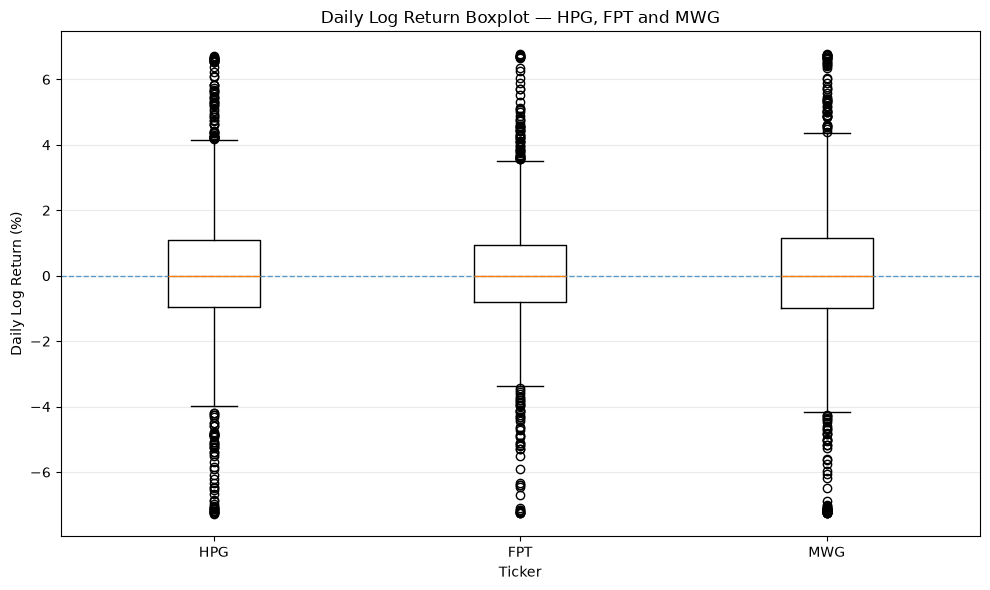

Đã lưu: /Users/admin/Documents/project/portfolio-var-risk-system/figures/eda/05_return_boxplot.png


In [103]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

boxplot_values = [
    (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            "log_return",
        ]
        .dropna()
        .to_numpy()
        * 100
    )
    for ticker in TICKERS
]

ax.boxplot(
    boxplot_values,
    tick_labels=TICKERS,
    showfliers=True,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Daily Log Return Boxplot — HPG, FPT and MWG"
)

ax.set_xlabel("Ticker")
ax.set_ylabel("Daily Log Return (%)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

boxplot_path = (
    FIGURE_DIR / "05_return_boxplot.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", boxplot_path)

### Nhận xét Outlier

- Cả ba ticker đều có quan sát vượt ngưỡng IQR: HPG có 128 phiên, FPT có 116 phiên và MWG có 120 phiên.
- HPG có return nhỏ nhất, đạt -7.2666% vào ngày 2025-04-03.
- FPT có return lớn nhất, đạt 6.7659% vào ngày 2021-01-29.
- Các phiên có return cực đoan vẫn được giữ nguyên vì extreme return không đồng nghĩa với lỗi dữ liệu.
- Những ngày biến động mạnh cần được đối chiếu với điều kiện thị trường, thông tin doanh nghiệp và corporate action trước khi kết luận là dữ liệu bất thường.

## 4. B2 — Correlation Analysis

Tương quan được tính từ daily log return đã được căn chỉnh theo ngày giao dịch.

Ý nghĩa sơ bộ:

- Tương quan cao cho thấy hai ticker thường biến động cùng chiều.
- Tương quan thấp có thể mang lại lợi ích đa dạng hóa tốt hơn.
- Phần này chưa thực hiện portfolio optimization.

correlation matrix

In [104]:
aligned_returns = (
    return_matrix[TICKERS]
    .dropna(how="any")
)

correlation_matrix = aligned_returns.corr()

print(
    "Số ngày được dùng để tính correlation:",
    len(aligned_returns),
)

correlation_matrix.round(4)

Số ngày được dùng để tính correlation: 1637


ticker,HPG,FPT,MWG
ticker,,,
HPG,1.0000,0.4926,0.5198
FPT,0.4926,1.0000,0.5423
MWG,0.5198,0.5423,1.0000


tìm cặp cao nhất và thấp nhất

In [105]:
upper_triangle_mask = np.triu(
    np.ones(
        correlation_matrix.shape,
        dtype=bool,
    ),
    k=1,
)

correlation_pairs = (
    correlation_matrix
    .where(upper_triangle_mask)
    .stack()
    .sort_values(ascending=False)
)

highest_pair = correlation_pairs.index[0]
highest_value = correlation_pairs.iloc[0]

lowest_pair = correlation_pairs.index[-1]
lowest_value = correlation_pairs.iloc[-1]

print(
    "Cặp tương quan cao nhất:",
    f"{highest_pair[0]} - {highest_pair[1]}",
    f"= {highest_value:.4f}",
)

print(
    "Cặp tương quan thấp nhất:",
    f"{lowest_pair[0]} - {lowest_pair[1]}",
    f"= {lowest_value:.4f}",
)

Cặp tương quan cao nhất: FPT - MWG = 0.5423
Cặp tương quan thấp nhất: HPG - FPT = 0.4926


heatmap correlation

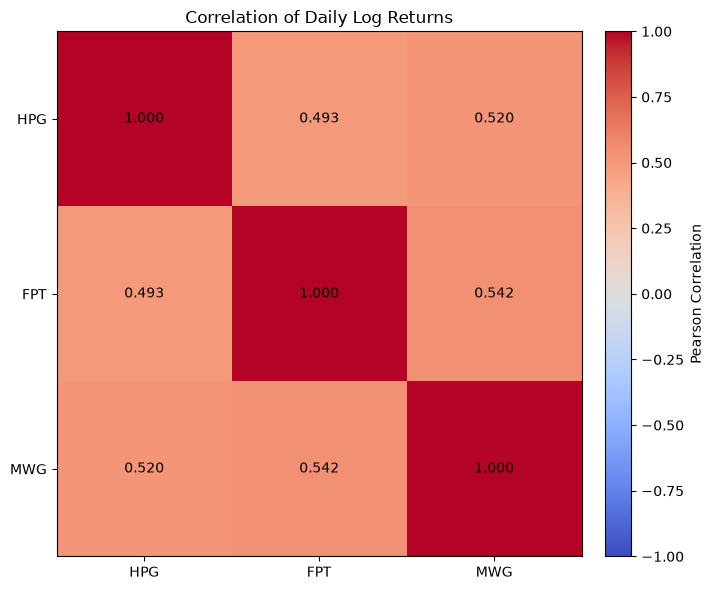

Đã lưu: /Users/admin/Documents/project/portfolio-var-risk-system/figures/eda/06_return_correlation.png


In [106]:
fig, ax = plt.subplots(
    figsize=(7, 6),
)

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(TICKERS)),
    labels=TICKERS,
)

ax.set_yticks(
    range(len(TICKERS)),
    labels=TICKERS,
)

for row in range(len(TICKERS)):
    for column in range(len(TICKERS)):
        value = correlation_matrix.iloc[
            row,
            column,
        ]

        ax.text(
            column,
            row,
            f"{value:.3f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Correlation of Daily Log Returns"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Pearson Correlation"
)

fig.tight_layout()

correlation_path = (
    FIGURE_DIR / "06_return_correlation.png"
)

fig.savefig(
    correlation_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", correlation_path)

### Nhận xét Correlation

- Cặp có tương quan cao nhất là FPT–MWG, với hệ số 0.5423.
- Cặp có tương quan thấp nhất là HPG–FPT, với hệ số 0.4926.
- Cả ba cặp đều có tương quan dương ở mức trung bình, cho thấy lợi suất có xu hướng biến động cùng chiều nhưng không hoàn toàn đồng nhất.
- HPG–FPT có tương quan thấp nhất nên có thể mang lại lợi ích đa dạng hóa sơ bộ tốt hơn hai cặp còn lại.
- Đây chỉ là phân tích mô tả; notebook chưa thực hiện portfolio optimization.

## 5. B3 — Rolling Volatility 20 phiên

Rolling volatility được tính bằng độ lệch chuẩn của daily log return trong cửa sổ 20 phiên:

\[
\sigma_{t,20}
=
Std(r_{t-19}, ..., r_t)
\]

Ở bước EDA này, volatility được giữ ở dạng daily volatility và chưa annualize.

tính rolling volatility

In [107]:
market_data["rolling_vol_20"] = (
    market_data
    .groupby("ticker")["log_return"]
    .transform(
        lambda series: (
            series
            .rolling(
                window=20,
                min_periods=20,
            )
            .std()
        )
    )
)

rolling_volatility_check = (
    market_data
    .groupby("ticker")
    .agg(
        valid_rolling_volatility=(
            "rolling_vol_20",
            "count",
        ),
        missing_rolling_volatility=(
            "rolling_vol_20",
            lambda series: series.isna().sum(),
        ),
    )
)

rolling_volatility_check

,valid_rolling_volatility,missing_rolling_volatility
ticker,,
FPT,1618,20
HPG,1618,20
MWG,1618,20


thống kê volatility

In [108]:
rolling_summary_rows = []

for ticker in TICKERS:
    ticker_data = (
        market_data
        .loc[
            market_data["ticker"] == ticker,
            ["time", "rolling_vol_20"],
        ]
        .dropna()
        .copy()
    )

    maximum_index = (
        ticker_data["rolling_vol_20"].idxmax()
    )

    rolling_summary_rows.append(
        {
            "ticker": ticker,
            "mean_rolling_vol_20": (
                ticker_data["rolling_vol_20"].mean()
            ),
            "median_rolling_vol_20": (
                ticker_data["rolling_vol_20"].median()
            ),
            "maximum_rolling_vol_20": (
                ticker_data.loc[
                    maximum_index,
                    "rolling_vol_20",
                ]
            ),
            "maximum_volatility_date": (
                ticker_data.loc[
                    maximum_index,
                    "time",
                ]
            ),
        }
    )


rolling_volatility_summary = pd.DataFrame(
    rolling_summary_rows
)

rolling_volatility_display = (
    rolling_volatility_summary.copy()
)

for column in [
    "mean_rolling_vol_20",
    "median_rolling_vol_20",
    "maximum_rolling_vol_20",
]:
    rolling_volatility_display[column] *= 100

rolling_volatility_display.round(4)

,ticker,mean_rolling_vol_20,median_rolling_vol_20,maximum_rolling_vol_20,maximum_volatility_date
0,HPG,1.9681,1.7981,4.9695,2022-12-02
1,FPT,1.6808,1.5998,3.9428,2020-04-06
2,MWG,2.0818,1.8596,5.2318,2020-04-07


biểu đồ rolling volatility

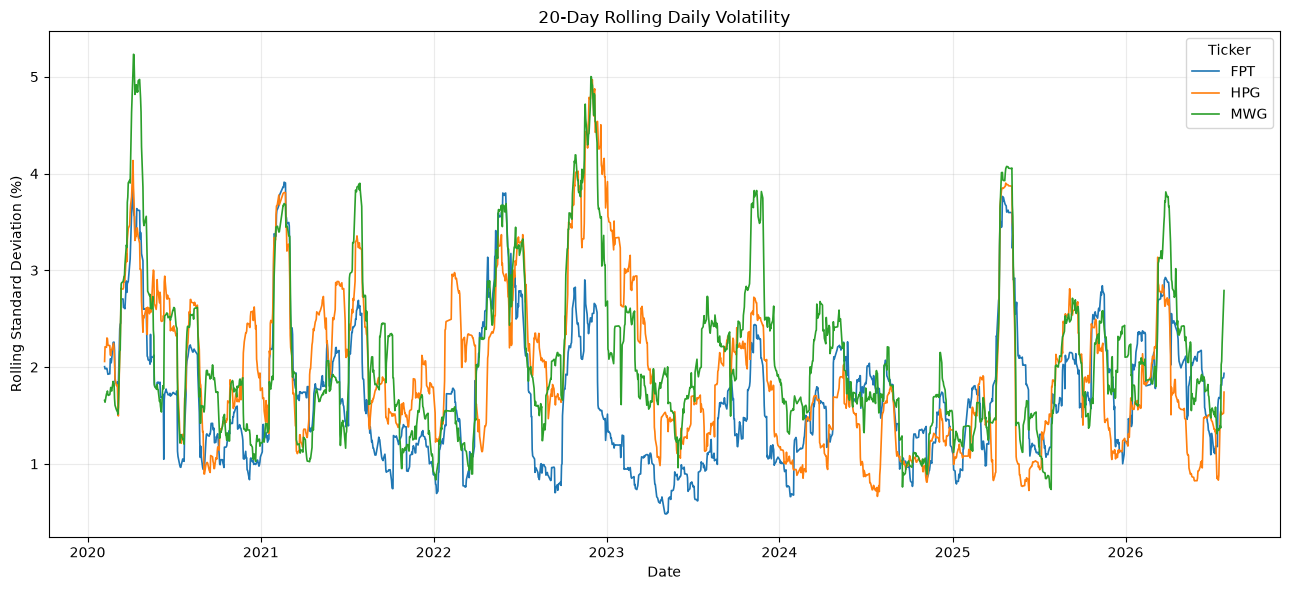

Đã lưu: /Users/admin/Documents/project/portfolio-var-risk-system/figures/eda/07_rolling_volatility_20d.png


In [109]:
fig, ax = plt.subplots(
    figsize=(13, 6),
)

for ticker, group in market_data.groupby("ticker"):
    ax.plot(
        group["time"],
        group["rolling_vol_20"] * 100,
        label=ticker,
        linewidth=1.2,
    )

ax.set_title(
    "20-Day Rolling Daily Volatility"
)

ax.set_xlabel("Date")
ax.set_ylabel(
    "Rolling Standard Deviation (%)"
)

ax.legend(title="Ticker")
ax.grid(alpha=0.25)

fig.tight_layout()

rolling_path = (
    FIGURE_DIR
    / "07_rolling_volatility_20d.png"
)

fig.savefig(
    rolling_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", rolling_path)

### Nhận xét Rolling Volatility

- MWG có rolling volatility 20 phiên trung bình cao nhất, đạt 2.0818%, tiếp theo là HPG với 1.9681% và FPT với 1.6808%.
- MWG cũng có mức rolling volatility cực đại cao nhất, đạt 5.2318% vào ngày 2020-04-07.
- HPG đạt cực đại 4.9695% vào ngày 2022-12-02, trong khi FPT đạt cực đại 3.9428% vào ngày 2020-04-06.
- Biểu đồ cho thấy volatility clustering: các giai đoạn biến động cao thường kéo dài thành cụm thay vì xuất hiện riêng lẻ.
- Rolling volatility là chỉ tiêu mô tả rủi ro trong quá khứ, chưa phải dự báo volatility tương lai.

## 6. B4 — Tail Behavior

Phân tích phần đuôi gồm:

- Quantile 1%.
- Quantile 5%.
- Quantile 95%.
- Quantile 99%.
- Skewness.
- Kurtosis.

Trong đó, `return_q05` là chỉ tiêu quan trọng nhất vì VaR 95% sau này tập trung vào 5% đuôi trái của phân phối lợi suất.

tail statistics

In [110]:
tail_statistics = (
    returns_data
    .groupby("ticker")["log_return"]
    .agg(
        observations="count",
        mean="mean",
        standard_deviation="std",
        skewness="skew",
        kurtosis=lambda series: series.kurt(),
    )
)

tail_quantiles = (
    returns_data
    .groupby("ticker")["log_return"]
    .quantile(
        [0.01, 0.05, 0.95, 0.99]
    )
    .unstack()
    .rename(
        columns={
            0.01: "return_q01",
            0.05: "return_q05",
            0.95: "return_q95",
            0.99: "return_q99",
        }
    )
)

tail_statistics = (
    tail_statistics
    .join(tail_quantiles)
)

tail_statistics

,observations,mean,standard_deviation,skewness,kurtosis,return_q01,return_q05,return_q95,return_q99
ticker,,,,,,,,,
FPT,1637,0.000674,0.018190,-0.061923,2.854547,-0.052955,-0.026561,0.031934,0.052359
HPG,1637,0.000639,0.021428,-0.117284,2.033945,-0.069467,-0.033679,0.038468,0.063311
MWG,1637,0.000347,0.022556,-0.312142,2.075760,-0.071645,-0.036333,0.037346,0.064940


hiển thị theo phần trăm

In [111]:
tail_statistics_display = (
    tail_statistics.copy()
)

percentage_columns = [
    "mean",
    "standard_deviation",
    "return_q01",
    "return_q05",
    "return_q95",
    "return_q99",
]

tail_statistics_display[
    percentage_columns
] = (
    tail_statistics_display[
        percentage_columns
    ] * 100
)

tail_statistics_display.round(4)

,observations,mean,standard_deviation,skewness,kurtosis,return_q01,return_q05,return_q95,return_q99
ticker,,,,,,,,,
FPT,1637,0.0674,1.8190,-0.0619,2.8545,-5.2955,-2.6561,3.1934,5.2359
HPG,1637,0.0639,2.1428,-0.1173,2.0339,-6.9467,-3.3679,3.8468,6.3311
MWG,1637,0.0347,2.2556,-0.3121,2.0758,-7.1645,-3.6333,3.7346,6.4940


các quan sát thuộc đuôi trái 5%

In [112]:
left_tail_rows = []

for ticker in TICKERS:
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            ["time", "ticker", "log_return"],
        ]
        .copy()
    )

    q05 = ticker_returns[
        "log_return"
    ].quantile(0.05)

    ticker_left_tail = (
        ticker_returns
        .loc[
            ticker_returns["log_return"] <= q05
        ]
        .assign(
            return_pct=lambda frame: (
                frame["log_return"] * 100
            )
        )
        .sort_values("log_return")
    )

    left_tail_rows.append(ticker_left_tail)


left_tail_observations = pd.concat(
    left_tail_rows,
    ignore_index=True,
)

left_tail_summary = (
    left_tail_observations
    .groupby("ticker")
    .agg(
        left_tail_rows=("time", "size"),
        earliest_tail_date=("time", "min"),
        latest_tail_date=("time", "max"),
        worst_tail_return_pct=(
            "return_pct",
            "min",
        ),
    )
)

left_tail_summary.round(4)

,left_tail_rows,earliest_tail_date,latest_tail_date,worst_tail_return_pct
ticker,,,,
FPT,82,2020-01-21,2026-07-24,-7.2460
HPG,82,2020-01-30,2026-07-20,-7.2666
MWG,82,2020-01-30,2026-07-27,-7.2602


biểu đồ left tail

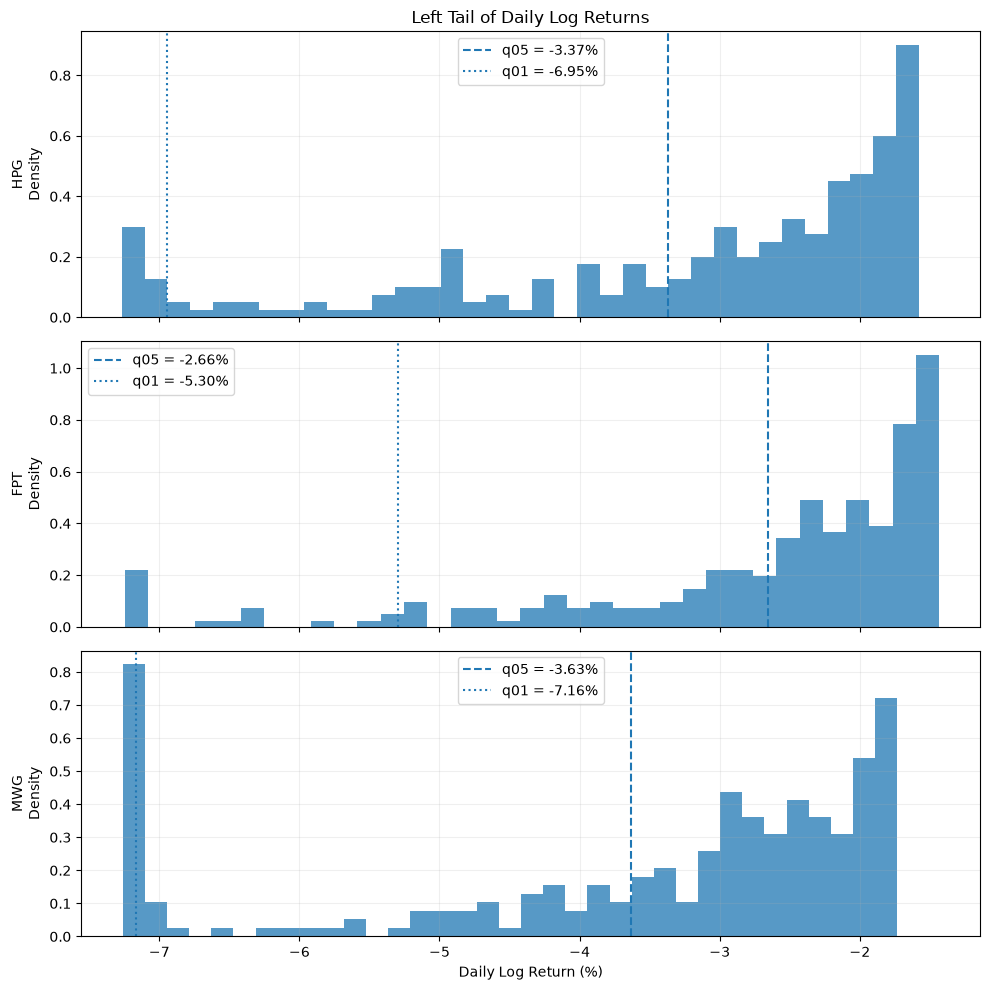

Đã lưu: /Users/admin/Documents/project/portfolio-var-risk-system/figures/eda/08_left_tail_returns.png


In [113]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 10),
    sharex=True,
)

for ax, ticker in zip(
    axes,
    TICKERS,
):
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            "log_return",
        ]
        .dropna()
        * 100
    )

    q01 = ticker_returns.quantile(0.01)
    q05 = ticker_returns.quantile(0.05)

    left_plot_limit = (
        ticker_returns.quantile(0.15)
    )

    plotted_returns = ticker_returns[
        ticker_returns <= left_plot_limit
    ]

    ax.hist(
        plotted_returns,
        bins=35,
        density=True,
        alpha=0.75,
    )

    ax.axvline(
        q05,
        linestyle="--",
        linewidth=1.5,
        label=f"q05 = {q05:.2f}%",
    )

    ax.axvline(
        q01,
        linestyle=":",
        linewidth=1.5,
        label=f"q01 = {q01:.2f}%",
    )

    ax.set_ylabel(
        f"{ticker}\nDensity"
    )

    ax.legend()
    ax.grid(alpha=0.2)


axes[0].set_title(
    "Left Tail of Daily Log Returns"
)

axes[-1].set_xlabel(
    "Daily Log Return (%)"
)

fig.tight_layout()

left_tail_path = (
    FIGURE_DIR
    / "08_left_tail_returns.png"
)

fig.savefig(
    left_tail_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", left_tail_path)

### Nhận xét Tail Behavior

- MWG có `return_q05` âm nhất, đạt -3.6333%, tiếp theo là HPG (-3.3679%) và FPT (-2.6561%).
- Điều này cho thấy MWG có ngưỡng tổn thất tại đuôi trái 5% sâu nhất trong ba ticker.
- Nếu xét return tối thiểu quan sát được, HPG có mức giảm sâu nhất là -7.2666%.
- Skewness của cả ba ticker đều âm: FPT -0.0619, HPG -0.1173 và MWG -0.3121. MWG có độ lệch âm mạnh nhất.
- Excess kurtosis của cả ba ticker đều dương: FPT 2.8545, HPG 2.0339 và MWG 2.0758, cho thấy phân phối lợi suất có đuôi dày hơn phân phối chuẩn.
- `return_q05` là chỉ tiêu quan trọng cho VaR 95%, vì đại diện cho ngưỡng của 5% lợi suất thấp nhất.

## 7. B5 — Derived Variables for Data Dictionary

Người B bổ sung các biến dẫn xuất vào Data Dictionary hiện có.

Không tạo Data Dictionary thứ hai.

bảng biến dẫn xuất

In [114]:
derived_variable_dictionary = pd.DataFrame(
    {
        "Variable": [
            "rolling_vol_20",
            "return_q05",
            "return_q01",
            "normalized_price",
        ],
        "Meaning": [
            (
                "Rolling standard deviation của "
                "daily log return trong 20 phiên"
            ),
            (
                "Phân vị 5% của daily log return"
            ),
            (
                "Phân vị 1% của daily log return"
            ),
            (
                "Giá đóng cửa chuẩn hóa về 100 "
                "tại ngày đầu"
            ),
        ],
    }
)

derived_variable_dictionary

,Variable,Meaning
0,rolling_vol_20,Rolling standard deviation của daily log retur...
1,return_q05,Phân vị 5% của daily log return
2,return_q01,Phân vị 1% của daily log return
3,normalized_price,Giá đóng cửa chuẩn hóa về 100 tại ngày đầu


## 8. Kiểm tra Deliverables

Notebook phải tạo đủ các hình:

- `05_return_boxplot.png`
- `06_return_correlation.png`
- `07_rolling_volatility_20d.png`
- `08_left_tail_returns.png`

kiểm tra hình

In [115]:
required_figures = [
    "05_return_boxplot.png",
    "06_return_correlation.png",
    "07_rolling_volatility_20d.png",
    "08_left_tail_returns.png",
]

figure_validation = pd.DataFrame(
    {
        "figure": required_figures,
        "exists": [
            (
                FIGURE_DIR / figure
            ).exists()
            for figure in required_figures
        ],
        "path": [
            str(FIGURE_DIR / figure)
            for figure in required_figures
        ],
    }
)

figure_validation

,figure,exists,path
0,05_return_boxplot.png,True,/Users/admin/Documents/project/portfolio-var-r...
1,06_return_correlation.png,True,/Users/admin/Documents/project/portfolio-var-r...
2,07_rolling_volatility_20d.png,True,/Users/admin/Documents/project/portfolio-var-r...
3,08_left_tail_returns.png,True,/Users/admin/Documents/project/portfolio-var-r...


báo lỗi nếu thiếu hình

In [116]:
if not figure_validation["exists"].all():
    missing_figures = (
        figure_validation
        .loc[
            ~figure_validation["exists"],
            "figure",
        ]
        .tolist()
    )

    raise RuntimeError(
        "Thiếu các hình: "
        + ", ".join(missing_figures)
    )

print("Đã tạo đủ 4 hình Risk-Oriented EDA.")

Đã tạo đủ 4 hình Risk-Oriented EDA.


## 9. Key Findings

### Outlier Analysis

- Ticker có return nhỏ nhất: **HPG (-7.2666%)** vào ngày **2025-04-03**.
- Ticker có return lớn nhất: **FPT (6.7659%)** vào ngày **2021-01-29**.
- Số quan sát vượt ngưỡng IQR của HPG: **128**.
- Số quan sát vượt ngưỡng IQR của FPT: **116**.
- Số quan sát vượt ngưỡng IQR của MWG: **120**.
- Không có outlier nào bị tự động xóa.

### Correlation Analysis

- Cặp có tương quan cao nhất: **FPT–MWG (0.5423)**.
- Cặp có tương quan thấp nhất: **HPG–FPT (0.4926)**.
- HPG–FPT có tương quan thấp nhất nên có thể mang lại lợi ích đa dạng hóa sơ bộ tốt hơn.

### Rolling Volatility

- Ticker có rolling volatility trung bình cao nhất: **MWG (2.0818%)**.
- Ticker có volatility cực đại cao nhất: **MWG (5.2318%)**.
- Ngày có volatility cực đại: **2020-04-07**.
- Biểu đồ cho thấy volatility clustering, với các giai đoạn biến động cao và thấp xuất hiện thành từng cụm.

### Tail Behavior

- Ticker có `return_q05` âm nhất: **MWG (-3.6333%)**.
- Nếu hiểu đuôi trái theo phân vị 5%, MWG có đuôi trái sâu nhất.
- Nếu xét return tối thiểu quan sát được, HPG có mức giảm sâu nhất là **-7.2666%**.
- Skewness của cả ba ticker đều âm: FPT **-0.0619**, HPG **-0.1173**, MWG **-0.3121**.
- Excess kurtosis của cả ba ticker đều dương: FPT **2.8545**, HPG **2.0339**, MWG **2.0758**.
- `return_q05` là chỉ tiêu quan trọng cho VaR 95%.

### Phạm vi

- Không thực hiện xóa outlier.
- Không thực hiện portfolio optimization.
- Không dự báo VaR trong notebook này.
- Notebook cung cấp đầu vào EDA cho các bước mô hình hóa rủi ro tiếp theo.